In [1]:
import nidaqmx
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

In [2]:
# -----------------------------
# DAQ settings
# -----------------------------
sample_rate = 50000
duration = 5.0
num_samples = int(sample_rate * duration)

pd_channel = "Dev1/ai2"
mon_channel = "Dev1/ai3"

In [3]:
def acquire_etalon_data(label, sample_rate, duration, pd_channel, mon_channel):
    num_samples = int(sample_rate * duration)

    with nidaqmx.Task() as task:
        task.ai_channels.add_ai_voltage_chan(pd_channel, min_val=-10, max_val=10)
        task.ai_channels.add_ai_voltage_chan(mon_channel, min_val=0, max_val=5)

        task.timing.cfg_samp_clk_timing(
            rate=sample_rate,
            sample_mode=nidaqmx.constants.AcquisitionType.FINITE,
            samps_per_chan=num_samples
        )

        print(f"Acquiring {label}...")
        data = task.read(
            number_of_samples_per_channel=num_samples,
            timeout=duration + 5
        )

    data = np.array(data)
    pd_signal = data[0]
    monitor_out = data[1]
    t = np.arange(num_samples) / sample_rate

    return {
        "label": label,
        "sample_rate": sample_rate,
        "duration": duration,
        "time": t,
        "pd_signal": pd_signal,
        "monitor_out": monitor_out
    }

In [4]:
# Take first dataset
input("Set the laser to the INITIAL wavelength, then press Enter to acquire...")
data_initial = acquire_etalon_data(
    label="initial_lambda",
    sample_rate=sample_rate,
    duration=duration,
    pd_channel=pd_channel,
    mon_channel=mon_channel
)

Set the laser to the INITIAL wavelength, then press Enter to acquire... 54


Acquiring initial_lambda...


In [12]:
# Take second dataset
input("Set the laser to the FINAL wavelength, then press Enter to acquire...")
data_final = acquire_etalon_data(
    label="final_lambda",
    sample_rate=sample_rate,
    duration=duration,
    pd_channel=pd_channel,
    mon_channel=mon_channel
)

Set the laser to the FINAL wavelength, then press Enter to acquire... 57


Acquiring final_lambda...


In [13]:
# Store both together
all_data = {
    "initial": data_initial,
    "final": data_final
}

print("Stored datasets:")
print(all_data.keys())

Stored datasets:
dict_keys(['initial', 'final'])


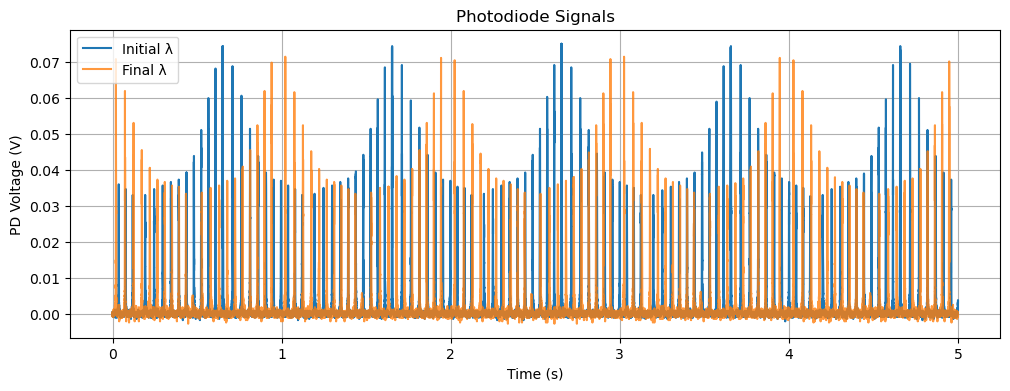

In [14]:
# Plot PD signals
plt.figure(figsize=(12, 4))
plt.plot(all_data["initial"]["time"], all_data["initial"]["pd_signal"], label="Initial λ")
plt.plot(all_data["final"]["time"], all_data["final"]["pd_signal"], label="Final λ", alpha=0.8)
plt.xlabel("Time (s)")
plt.ylabel("PD Voltage (V)")
plt.title("Photodiode Signals")
plt.grid(True)
plt.legend()
plt.show()

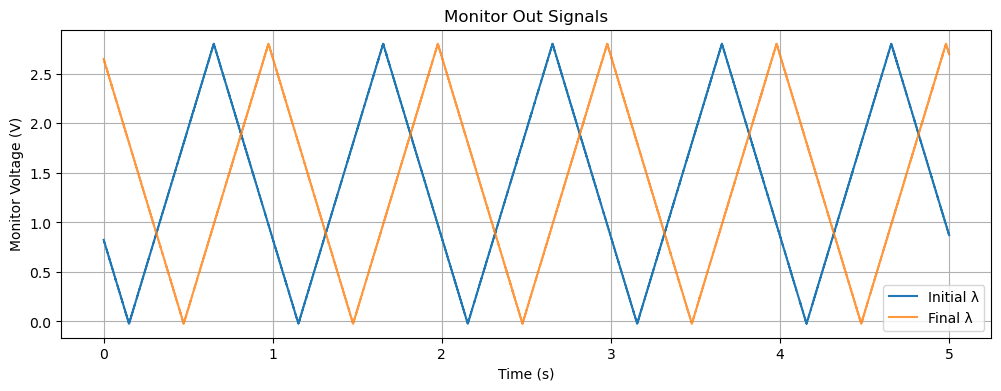

In [15]:
# Plot Monitor signals
plt.figure(figsize=(12, 4))
plt.plot(all_data["initial"]["time"], all_data["initial"]["monitor_out"], label="Initial λ")
plt.plot(all_data["final"]["time"], all_data["final"]["monitor_out"], label="Final λ", alpha=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Monitor Voltage (V)")
plt.title("Monitor Out Signals")
plt.grid(True)
plt.legend()
plt.show()

In [16]:
# Optional: save to disk so you can load later
np.savez(
    "etalon_two_wavelength_data.npz",
    t_initial=all_data["initial"]["time"],
    pd_initial=all_data["initial"]["pd_signal"],
    mon_initial=all_data["initial"]["monitor_out"],
    t_final=all_data["final"]["time"],
    pd_final=all_data["final"]["pd_signal"],
    mon_final=all_data["final"]["monitor_out"],
)
print("Saved to etalon_two_wavelength_data.npz")

Saved to etalon_two_wavelength_data.npz


In [78]:
init_mon = all_data["initial"]["monitor_out"]
final_mon = all_data["final"]["monitor_out"]

t_init = all_data["initial"]["time"]
t_final = all_data["final"]["time"]

# Remove mean before correlation
x = init_mon - np.mean(init_mon)
y = final_mon - np.mean(final_mon)

corr = np.correlate(x, y, mode="full")
lags = np.arange(-len(y) + 1, len(x))

best_lag = lags[np.argmax(corr)]
time_shift = best_lag / sample_rate

print("Best lag (samples):", best_lag)
print("Time shift (s):", time_shift)

t_final_shifted = t_final + time_shift

Best lag (samples): -15849
Time shift (s): -0.31698


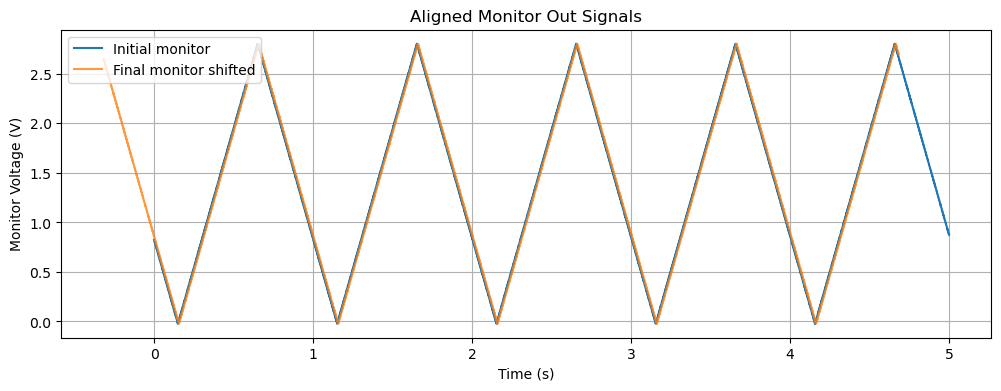

In [80]:
plt.figure(figsize=(12,4))
plt.plot(t_init, init_mon, label="Initial monitor")
plt.plot(t_final_shifted, final_mon, label="Final monitor shifted", alpha=0.8)

plt.xlabel("Time (s)")
plt.ylabel("Monitor Voltage (V)")
plt.title("Aligned Monitor Out Signals")
plt.grid(True)
plt.legend()
plt.show()

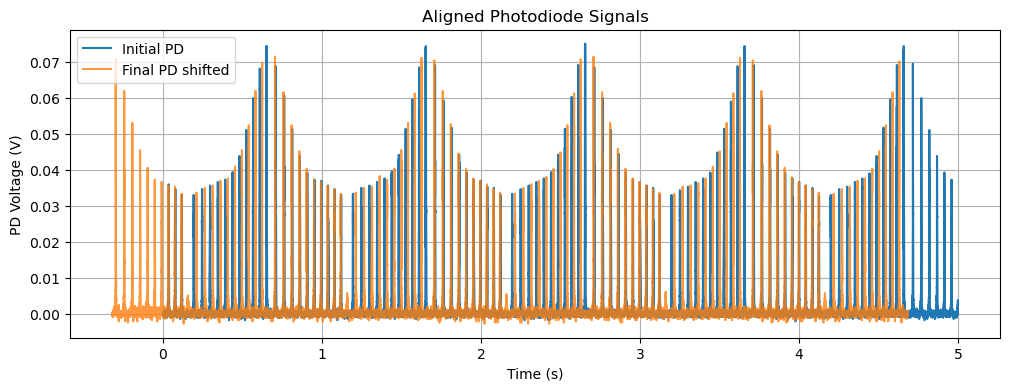

In [81]:
plt.figure(figsize=(12,4))
plt.plot(all_data["initial"]["time"], all_data["initial"]["pd_signal"], label="Initial PD")
plt.plot(t_final_shifted, all_data["final"]["pd_signal"], label="Final PD shifted", alpha=0.8)
plt.xlabel("Time (s)")
plt.ylabel("PD Voltage (V)")
plt.title("Aligned Photodiode Signals")
plt.grid(True)
plt.legend()
plt.show()

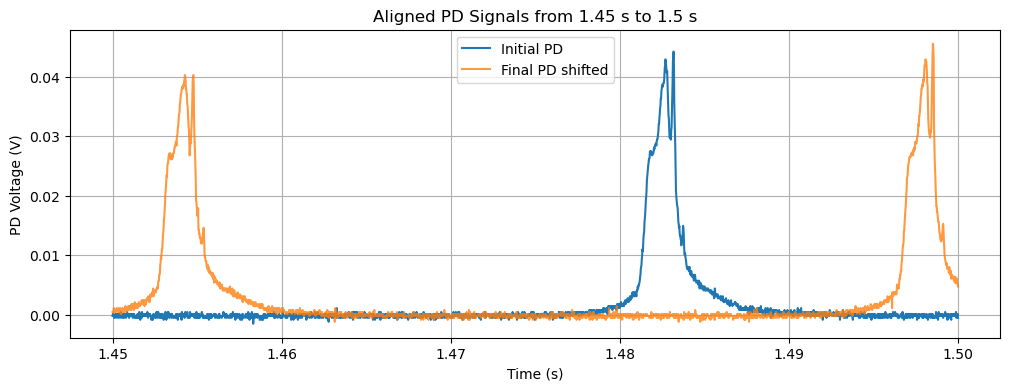

In [82]:
t_start = 1.45
t_end = 1.5

mask_init = (all_data["initial"]["time"] >= t_start) & (all_data["initial"]["time"] <= t_end)
mask_final = (t_final_shifted >= t_start) & (t_final_shifted <= t_end)

plt.figure(figsize=(12,4))
plt.plot(all_data["initial"]["time"][mask_init], all_data["initial"]["pd_signal"][mask_init], label="Initial PD")
plt.plot(t_final_shifted[mask_final], all_data["final"]["pd_signal"][mask_final], label="Final PD shifted", alpha=0.8)
plt.xlabel("Time (s)")
plt.ylabel("PD Voltage (V)")
plt.title(f"Aligned PD Signals from {t_start} s to {t_end} s")
plt.grid(True)
plt.legend()
plt.show()

In [83]:
# Choose one aligned window
t_start = 0.0
t_end = 5.0

In [84]:
from scipy.signal import find_peaks, savgol_filter
import numpy as np
import matplotlib.pyplot as plt

# Smooth monitor only for turning-point detection
init_mon_for_turns = savgol_filter(init_mon, 101, 2)
final_mon_for_turns = savgol_filter(final_mon, 101, 2)

# Same-type turning points are about 1 second apart
distance_samples = int(0.8 * sample_rate)

# Require strong extrema only
prominence_val = 0.5

init_max_idx, _ = find_peaks(init_mon_for_turns, distance=distance_samples, prominence=prominence_val)
init_min_idx, _ = find_peaks(-init_mon_for_turns, distance=distance_samples, prominence=prominence_val)

final_max_idx, _ = find_peaks(final_mon_for_turns, distance=distance_samples, prominence=prominence_val)
final_min_idx, _ = find_peaks(-final_mon_for_turns, distance=distance_samples, prominence=prominence_val)

print("Initial max count:", len(init_max_idx))
print("Initial min count:", len(init_min_idx))
print("Final max count:", len(final_max_idx))
print("Final min count:", len(final_min_idx))

Initial max count: 5
Initial min count: 5
Final max count: 4
Final min count: 5


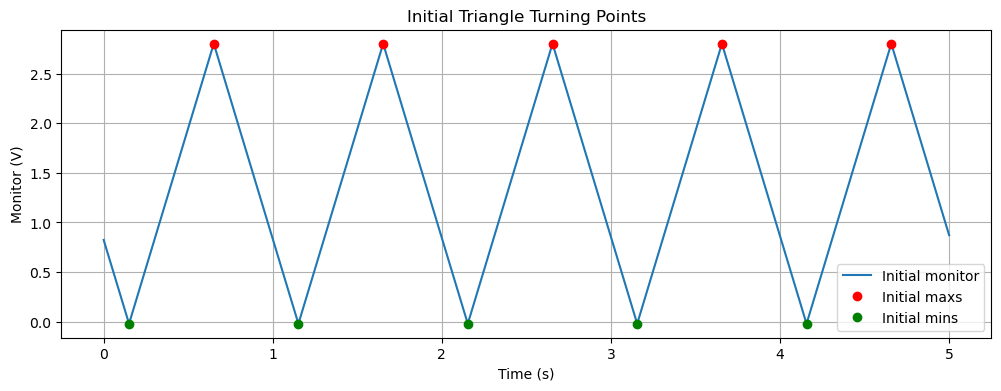

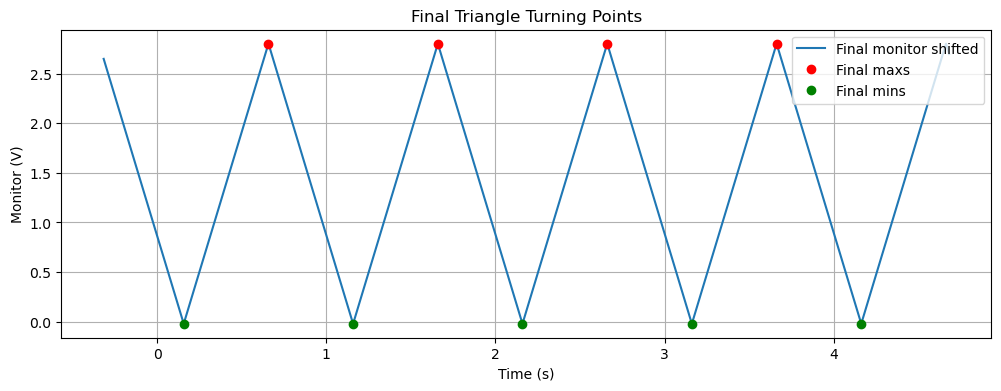

In [85]:
plt.figure(figsize=(12,4))
plt.plot(t_init, init_mon_for_turns, label="Initial monitor")
plt.plot(t_init[init_max_idx], init_mon_for_turns[init_max_idx], "ro", label="Initial maxs")
plt.plot(t_init[init_min_idx], init_mon_for_turns[init_min_idx], "go", label="Initial mins")
plt.xlabel("Time (s)")
plt.ylabel("Monitor (V)")
plt.title("Initial Triangle Turning Points")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(t_final_shifted, final_mon_for_turns, label="Final monitor shifted")
plt.plot(t_final_shifted[final_max_idx], final_mon_for_turns[final_max_idx], "ro", label="Final maxs")
plt.plot(t_final_shifted[final_min_idx], final_mon_for_turns[final_min_idx], "go", label="Final mins")
plt.xlabel("Time (s)")
plt.ylabel("Monitor (V)")
plt.title("Final Triangle Turning Points")
plt.grid(True)
plt.legend()
plt.show()

In [86]:
ramp_number = 2

start_init = init_min_idx[ramp_number]
start_final = final_min_idx[ramp_number]

end_init = init_max_idx[init_max_idx > start_init][0]
end_final = final_max_idx[final_max_idx > start_final][0]

print("Initial ramp-up:", t_init[start_init], "to", t_init[end_init])
print("Final ramp-up:", t_final_shifted[start_final], "to", t_final_shifted[end_final])

Initial ramp-up: 2.15332 to 2.65452
Final ramp-up: 2.1598 to 2.661


In [87]:
t_init = all_data["initial"]["time"]
pd_init = all_data["initial"]["pd_signal"]
mon_init = all_data["initial"]["monitor_out"]

t_final = all_data["final"]["time"]
pd_final = all_data["final"]["pd_signal"]
mon_final = all_data["final"]["monitor_out"]

In [88]:
# Align the ramp starts directly
time_shift_refined = t_init[start_init] - t_final[start_final]

print("Refined time shift (s):", time_shift_refined)

t_final_shifted = t_final + time_shift_refined

Refined time shift (s): -0.3234600000000003


In [89]:
t_init_win = t_init[start_init:end_init]
pd_init_win = pd_init[start_init:end_init]
mon_init_win = mon_init[start_init:end_init]

t_final_win = t_final_shifted[start_final:end_final]
pd_final_win = pd_final[start_final:end_final]
mon_final_win = mon_final[start_final:end_final]

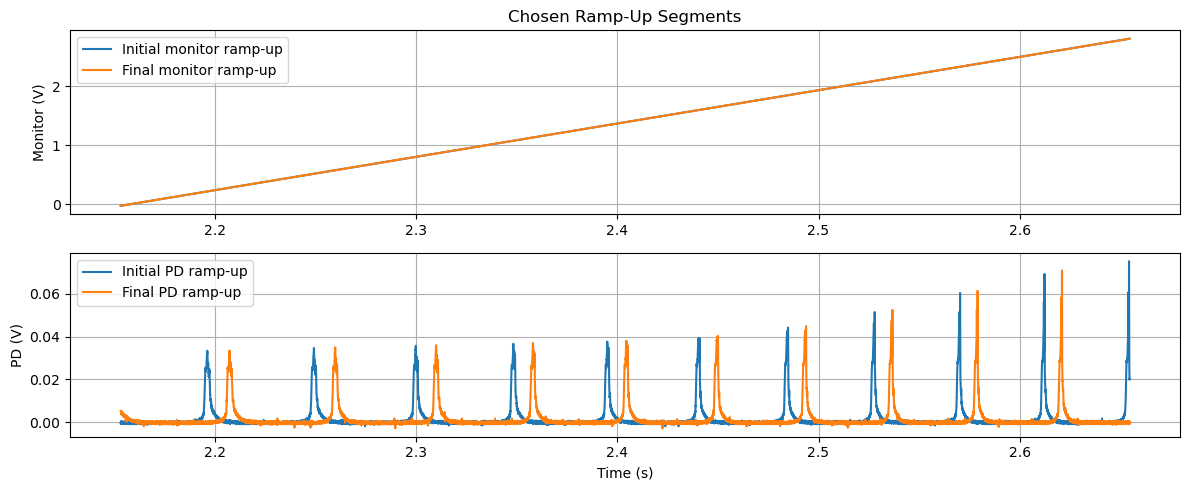

In [90]:
plt.figure(figsize=(12,5))

plt.subplot(2,1,1)
plt.plot(t_init_win, mon_init_win, label="Initial monitor ramp-up")
plt.plot(t_final_win, mon_final_win, label="Final monitor ramp-up")
plt.ylabel("Monitor (V)")
plt.title("Chosen Ramp-Up Segments")
plt.grid(True)
plt.legend()

plt.subplot(2,1,2)
plt.plot(t_init_win, pd_init_win, label="Initial PD ramp-up")
plt.plot(t_final_win, pd_final_win, label="Final PD ramp-up")
plt.xlabel("Time (s)")
plt.ylabel("PD (V)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [91]:
peak_prominence = 0.03
peak_distance_samples = 150

peaks_init, _ = find_peaks(
    pd_init_win,
    prominence=peak_prominence,
    distance=peak_distance_samples
)

peaks_final, _ = find_peaks(
    pd_final_win,
    prominence=peak_prominence,
    distance=peak_distance_samples
)

print("Initial peaks found:", len(peaks_init))
print("Final peaks found:", len(peaks_final))

Initial peaks found: 11
Final peaks found: 10


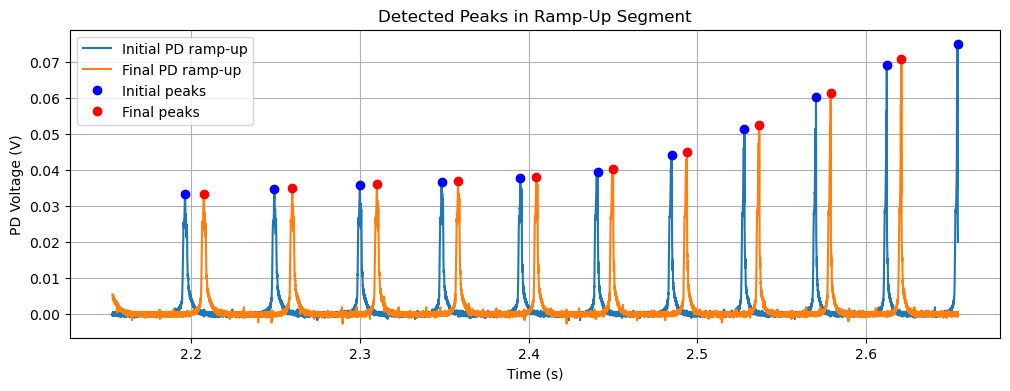

In [92]:
plt.figure(figsize=(12,4))
plt.plot(t_init_win, pd_init_win, label="Initial PD ramp-up")
plt.plot(t_final_win, pd_final_win, label="Final PD ramp-up")

plt.plot(t_init_win[peaks_init], pd_init_win[peaks_init], "bo", label="Initial peaks")
plt.plot(t_final_win[peaks_final], pd_final_win[peaks_final], "ro", label="Final peaks")

plt.xlabel("Time (s)")
plt.ylabel("PD Voltage (V)")
plt.title("Detected Peaks in Ramp-Up Segment")
plt.grid(True)
plt.legend()
plt.show()

In [93]:
n_pairs = min(len(peaks_init), len(peaks_final))

paired_peaks_init = peaks_init[:n_pairs]
paired_peaks_final = peaks_final[:n_pairs]

print("Number of paired peaks:", n_pairs)

Number of paired peaks: 10


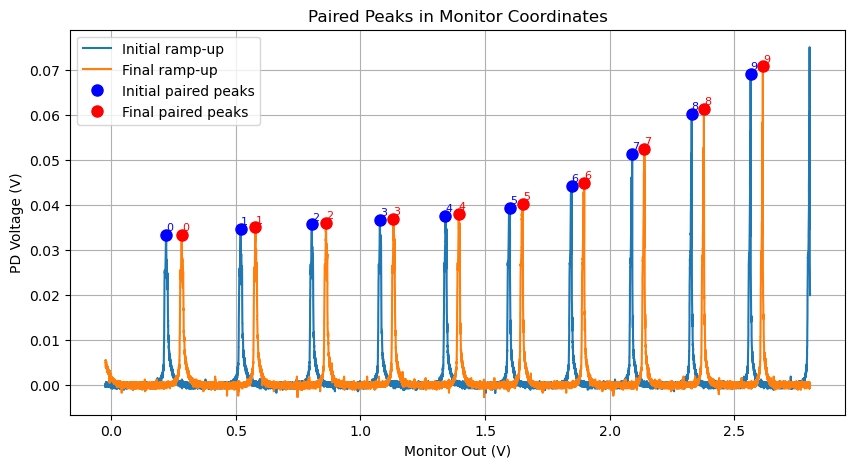

In [94]:
plt.figure(figsize=(10,5))
plt.plot(mon_init_win, pd_init_win, label="Initial ramp-up")
plt.plot(mon_final_win, pd_final_win, label="Final ramp-up")

plt.plot(mon_init_win[paired_peaks_init], pd_init_win[paired_peaks_init], "bo", markersize=8, label="Initial paired peaks")
plt.plot(mon_final_win[paired_peaks_final], pd_final_win[paired_peaks_final], "ro", markersize=8, label="Final paired peaks")

for i in range(n_pairs):
    plt.text(mon_init_win[paired_peaks_init][i], pd_init_win[paired_peaks_init][i] + 0.001, str(i), color="blue", fontsize=8)
    plt.text(mon_final_win[paired_peaks_final][i], pd_final_win[paired_peaks_final][i] + 0.001, str(i), color="red", fontsize=8)

plt.xlabel("Monitor Out (V)")
plt.ylabel("PD Voltage (V)")
plt.title("Paired Peaks in Monitor Coordinates")
plt.grid(True)
plt.legend()
plt.show()

In [95]:
mon_paired_init = mon_init_win[paired_peaks_init]
mon_paired_final = mon_final_win[paired_peaks_final]

pd_paired_init = pd_init_win[paired_peaks_init]
pd_paired_final = pd_final_win[paired_peaks_final]

delta_mon = mon_paired_final - mon_paired_init

print("Initial paired monitor positions:")
print(mon_paired_init)

print("\nFinal paired monitor positions:")
print(mon_paired_final)

print("\nMonitor shifts:")
print(delta_mon)

print("\nMean monitor shift:", np.mean(delta_mon))
print("Median monitor shift:", np.median(delta_mon))

Initial paired monitor positions:
[0.2205474  0.51921794 0.80441    1.07793174 1.34093383 1.59949823
 1.84721427 2.08999953 2.32884029 2.565216  ]

Final paired monitor positions:
[0.2831745  0.57872196 0.86177721 1.13250464 1.39435619 1.65127692
 1.89767805 2.1391484  2.37782492 2.61436514]

Monitor shifts:
[0.0626271  0.05950402 0.05736721 0.0545729  0.05342236 0.05177869
 0.05046378 0.04914888 0.04898462 0.04914913]

Mean monitor shift: 0.05370186878267136
Median monitor shift: 0.05260052386097869


In [96]:
mon_peak_positions = mon_paired_init

spacing_V = np.diff(mon_peak_positions)
spacing_midpoints = 0.5 * (mon_peak_positions[:-1] + mon_peak_positions[1:])

print("Local spacing in monitor volts (1 FSR each):")
print(spacing_V)

Local spacing in monitor volts (1 FSR each):
[0.29867055 0.28519205 0.27352174 0.26300209 0.2585644  0.24771604
 0.24278526 0.23884077 0.23637571]


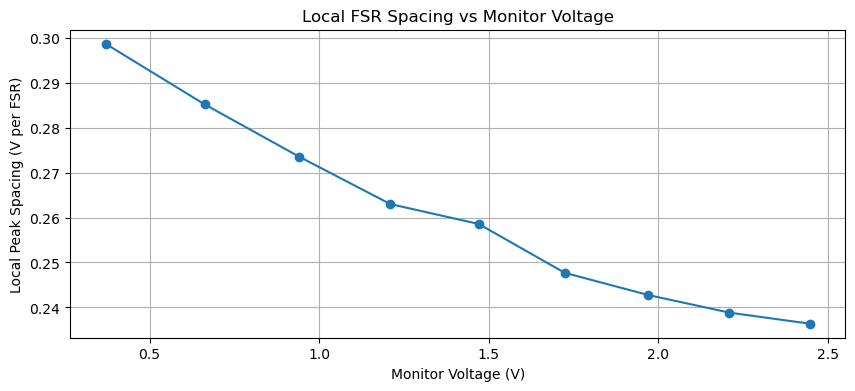

In [97]:
plt.figure(figsize=(10,4))
plt.plot(spacing_midpoints, spacing_V, "o-")
plt.xlabel("Monitor Voltage (V)")
plt.ylabel("Local Peak Spacing (V per FSR)")
plt.title("Local FSR Spacing vs Monitor Voltage")
plt.grid(True)
plt.show()

In [98]:
def fsr_spacing_from_monitor(V_query, spacing_midpoints, spacing_V):
    return np.interp(V_query, spacing_midpoints, spacing_V)

In [99]:
V_ref = 0.5 * (mon_paired_init + mon_paired_final)
local_spacing = fsr_spacing_from_monitor(V_ref, spacing_midpoints, spacing_V)

delta_FSR_local = delta_mon / local_spacing

print("Local fractional FSR shifts:")
print(delta_FSR_local)

print("\nMean delta FSR:", np.mean(delta_FSR_local))
print("Median delta FSR:", np.median(delta_FSR_local))

Local fractional FSR shifts:
[0.20968622 0.20490219 0.20632959 0.20432494 0.20522604 0.20554074
 0.20621149 0.20445107 0.20638335 0.20792802]

Mean delta FSR: 0.20609836508796214
Median delta FSR: 0.20587611557044241


In [100]:
FSR_GHz = 10.0
lambda0_nm = 635.0
c = 299792458.0

lambda0_m = lambda0_nm * 1e-9
nm_per_GHz = (lambda0_m**2 / c) * 1e9 * 1e9

delta_f_GHz_local = delta_FSR_local * FSR_GHz
delta_lambda_nm_local = delta_f_GHz_local * nm_per_GHz

print("Delta lambda for each pair (nm):")
print(delta_lambda_nm_local)

print("\nMean delta lambda (nm):", np.mean(delta_lambda_nm_local))
print("Median delta lambda (nm):", np.median(delta_lambda_nm_local))

Delta lambda for each pair (nm):
[0.00282031 0.00275596 0.00277516 0.0027482  0.00276032 0.00276455
 0.00277357 0.0027499  0.00277588 0.00279666]

Mean delta lambda (nm): 0.0027720514991272254
Median delta lambda (nm): 0.0027690622123953384


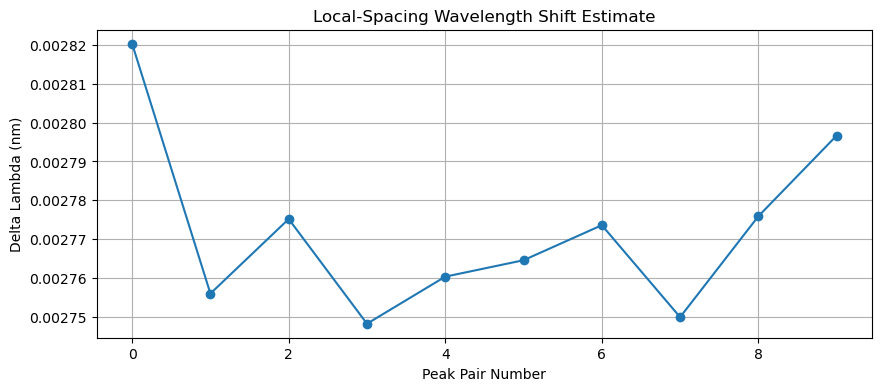

In [101]:
plt.figure(figsize=(10,4))
plt.plot(np.arange(len(delta_lambda_nm_local)), delta_lambda_nm_local, "o-")
plt.xlabel("Peak Pair Number")
plt.ylabel("Delta Lambda (nm)")
plt.title("Local-Spacing Wavelength Shift Estimate")
plt.grid(True)
plt.show()

In [102]:
delta_lambda_trim = delta_lambda_nm_local[1:]

print("Trimmed mean delta lambda (nm):", np.mean(delta_lambda_trim))
print("Trimmed median delta lambda (nm):", np.median(delta_lambda_trim))

Trimmed mean delta lambda (nm): 0.002766689594012316
Trimmed median delta lambda (nm): 0.00276455131780764


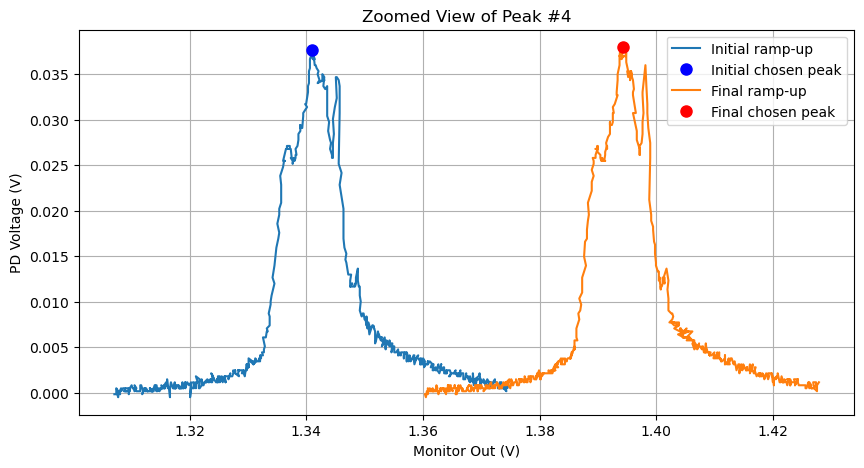

In [103]:
k = 4 # which paired peak to inspect
window = 300   # samples to show on each side

# peak sample indices
i0 = peaks_init[k]
f0 = peaks_final[k]

# slice around each peak
i_start = max(0, i0 - window)
i_end   = min(len(pd_init_win), i0 + window)

f_start = max(0, f0 - window)
f_end   = min(len(pd_final_win), f0 + window)

plt.figure(figsize=(10,5))

# initial
plt.plot(mon_init_win[i_start:i_end], pd_init_win[i_start:i_end], label="Initial ramp-up")
plt.plot(mon_init_win[i0], pd_init_win[i0], "bo", markersize=8, label="Initial chosen peak")

# final
plt.plot(mon_final_win[f_start:f_end], pd_final_win[f_start:f_end], label="Final ramp-up")
plt.plot(mon_final_win[f0], pd_final_win[f0], "ro", markersize=8, label="Final chosen peak")

plt.xlabel("Monitor Out (V)")
plt.ylabel("PD Voltage (V)")
plt.title(f"Zoomed View of Peak #{k}")
plt.grid(True)
plt.legend()
plt.show()